In [1]:
%load_ext autoreload
%autoreload

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import xeofs as xe
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import warnings
import sys
from mpl_toolkits.basemap import Basemap
import os
import requests
from bs4 import BeautifulSoup
#import copernicusmarine as cm
warnings.filterwarnings('ignore')
from scipy.interpolate import RegularGridInterpolator

In [3]:
# constant
rho_a = 1.225  # air density kg m-3
Cd = 1.5e-3  # drag coeff

gridtype = 'remapcon'

KeysView(<xarray.Dataset> Size: 201kB
Dimensions:     (lon: 360, lat: 64, c: 570)
Coordinates:
  * lon         (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat         (lat) float64 512B -81.75 -81.25 -80.75 ... -51.25 -50.75 -50.25
  * c           (c) int64 5kB 0 1 2 3 4 5 6 7 ... 563 564 565 566 567 568 569
Data variables:
    bathy_mask  (lon, lat) float64 184kB ...
    llon        (c) float64 5kB ...
    llat        (c) float64 5kB ...)
Defining map area ...

Getting coastlines north of 60 S ... 

Importing Antarctic Digital Database shapefile. 

<xarray.Dataset> Size: 249MB
Dimensions:          (longitude: 360, latitude: 64, time: 270, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-07-01 ... 2024-12-01
  * edge_lat         (edge_lat) float64 52

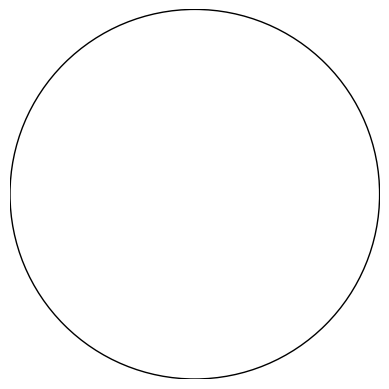

In [4]:
path = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
data_dir = path + 'Data/'
script_dir = path + 'Scripts/'
auxscriptdir = script_dir + 'aux_scripts/'
file_dir = data_dir + 'dot_all_30bmedian_egm2008_sig3.nc'

sys.path.append(auxscriptdir)
from pygments.modeline import modeline_re
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import aux_stereoplot as st
import aux_func as ft


ds = xr.open_dataset(file_dir)
print(ds)
# --- Mask out bad months ---
good_months = ds['bad_month_flag'] == 0
ds = ds.isel(time=good_months)

land_mask = ds.land_mask

In [5]:
# lon_min = 150     # example 1
# lon_max = -80    # example 1

lon_min = -90   # example 2
lon_max = 90    # example 2

lon = ds.longitude
lat = ds.latitude

if lon_min < lon_max:
    mask = (lon >= lon_min) & (lon <= lon_max)
else:
    mask = (lon >= lon_min) | (lon <= lon_max)

ds_reg = ds.sel(longitude=lon[mask])

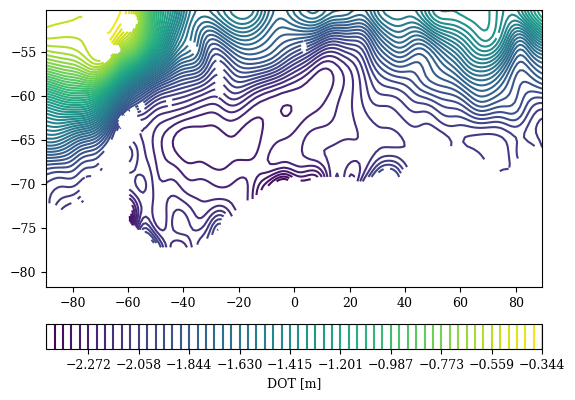

In [6]:
dot = ds_reg.dot

t = dot.time[100]
one_dot = dot.sel(time=t)

lon_one_time = one_dot.longitude.values
lat_one_time = one_dot.latitude.values
dot_one_time = one_dot.values.T    # contour expects (y,x) orientation

levels = np.linspace(np.nanmin(dot_one_time), np.nanmax(dot_one_time), 60)
cs = plt.contour(lon_one_time, lat_one_time, dot_one_time, levels=levels)
plt.colorbar(cs, orientation='horizontal', pad=0.1, label='DOT [m]')


In [120]:
def extract_closed_contours(
    lon, lat, variable, levels,
    lon_min, lon_max,
    land_mask_on_dot, dist_interp,
    tol=1e-6
):

    mask_interp = RegularGridInterpolator(
        (lat, lon),
        land_mask_on_dot,
        bounds_error=False,
        fill_value=0
    )

    cs = plt.contourf(lon, lat, variable, levels=levels)
    closed = []

    lat_min, lat_max = lat.min(), lat.max()

    for level, seglist in zip(cs.levels, cs.allsegs):
        for seg in seglist:

            # must have enough points
            if seg.shape[0] < 4:
                continue

            # must be geometrically closed
            if not np.allclose(seg[0], seg[-1], atol=tol):
                continue

            # --- continuity test (reject stitched/broken contours) ---
            d = np.sqrt(np.diff(seg[:,0])**2 + np.diff(seg[:,1])**2)
            if np.any(d > 1.5):   # ~20 km
                continue
            #
            # # --- reject contours within 10 km of latitude boundaries ---
            # lat_buffer = 10 / 111.0
            # if (
            #     np.any(seg[:,1] < lat_min + lat_buffer) or
            #     np.any(seg[:,1] > lat_max - lat_buffer)
            # ):
            #     continue
            #
            # # --- reject contours within 10 km of longitude boundaries ---
            # lon_buffer = 10 / (111.0 * np.cos(np.deg2rad(seg[:,1])))
            # if (
            #     np.any(seg[:,0] < lon_min + lon_buffer) or
            #     np.any(seg[:,0] > lon_max - lon_buffer)
            # ):
            #     continue
            #
            # # --- reject contours crossing meridian ---
            # if np.any(np.abs(np.diff(seg[:,0])) > 180):
            #     continue
            #
            # # --- reject contours touching land ---
            # mask_vals = mask_interp(seg[:, ::-1])
            # if np.any(mask_vals > 0.5):
            #     continue
            #
            # # --- reject contours within 10 km of land ---
            # dist_vals = dist_interp(seg[:, ::-1])
            # if np.any(dist_vals < 10):
            #     continue

            # --- compute area ---
            xs = seg[:, 0]
            ys = seg[:, 1]
            area = 0.5 * np.abs(
                np.dot(xs, np.roll(ys, 1)) -
                np.dot(ys, np.roll(xs, 1))
            )

            closed.append({
                "level": level,
                "vertices": seg,
                "area": area
            })

    plt.close()
    return closed


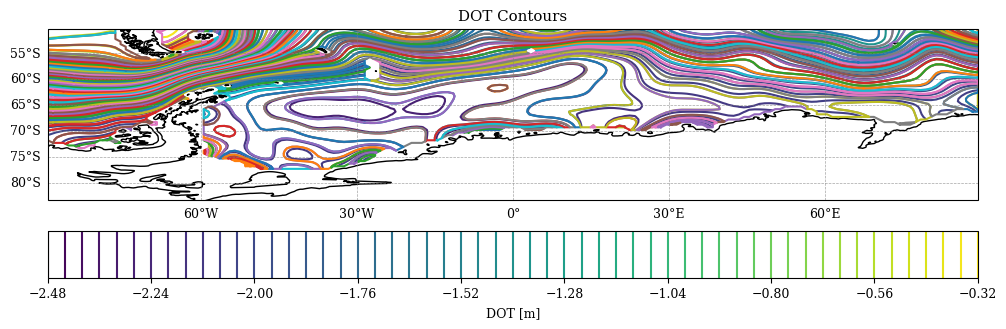

In [121]:
t = ds.time[100]   # change index as needed
field = ds.sel(time=t)

# x2 = ds.longitude.values
# y2 = ds.latitude.values
# z2 = field.dot.T

lon_one_time = one_dot.longitude.values
lat_one_time = one_dot.latitude.values
dot_one_time = one_dot.values.T    # contour expects (y,x) orientation


# --- existing code ---
land_lat = ds.land_mask.latitude.values
land_lon = ds.land_mask.longitude.values
land_mask = ds.land_mask.values

mask_land_interp = RegularGridInterpolator(
    (land_lat, land_lon),
    land_mask.T,
    bounds_error=False,
    fill_value=0
)

LAT, LON = np.meshgrid(lat_one_time, lon_one_time, indexing='ij')
land_mask_on_dot = mask_land_interp(np.stack([LAT, LON], axis=-1))

# --- NEW: compute distance-to-land field (in km) ---
from scipy.ndimage import distance_transform_edt

# ocean = 1, land = 0
ocean_mask = 1 - land_mask_on_dot

# distance in grid cells
dist_cells = distance_transform_edt(ocean_mask)

# convert to km
DX = 111.0 * np.cos(np.deg2rad(lat_one_time))[:, None]   # km per degree lon
DY = 111.0                                               # km per degree lat

dist_km = np.sqrt((dist_cells * DX)**2 + (dist_cells * DY)**2)

# interpolator for distance-to-land
dist_interp = RegularGridInterpolator(
    (lat_one_time, lon_one_time),
    dist_km,
    bounds_error=False,
    fill_value=np.inf
)

# --- extract closed contours on the wrapped grid ---
closed = extract_closed_contours(lon_one_time, lat_one_time, dot_one_time, levels, lon_min, lon_max, land_mask_on_dot, dist_interp)

fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- plot the other grid (unwrapped -180 to 180) ---
plt.contour(lon_one_time, lat_one_time, dot_one_time, levels=60, cmap='viridis')
# --- overlay contours, converting them to the target grid domain ---
for c in closed:
    seg = c["vertices"]

    # convert 0–360 → −180 → 180
    seg_lon = ((seg[:,0] + 180) % 360) - 180
    seg_lat = seg[:,1]

    plt.plot(seg_lon, seg_lat, '-', lw=1.5)

plt.colorbar( orientation='horizontal', pad=0.05, label='DOT [m]')

# Add gridlines with labels
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.7,
    linestyle='--'
)

# Optional: turn off top/right labels
gl.top_labels = False
gl.right_labels = False

ax.coastlines()
# ax.gridlines(draw_labels=True)
plt.title("DOT Contours")
plt.show()

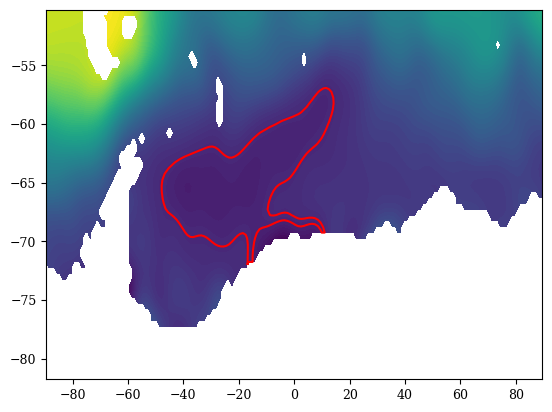

In [122]:
# --- select largest contour ---
valid = extract_closed_contours(
    lon_one_time, lat_one_time, dot_one_time,
    levels, lon_min, lon_max, land_mask_on_dot, dist_interp
)

if len(valid) == 0:
    print("No valid closed contours found.")
else:
    largest = max(valid, key=lambda c: c["area"])

# --- plot background field ---
plt.contourf(lon_one_time, lat_one_time, dot_one_time, levels=100, cmap='viridis')

# --- plot largest contour ---
seg = largest["vertices"]
seg_lon = ((seg[:,0] + 180) % 360) - 180
seg_lat = seg[:,1]
plt.plot(seg_lon, seg_lat, '-', lw=1.5, color='red')


In [76]:
# --- Extract DOT field for one time ---
dot = ds_reg.dot
t = dot.time[100]
one_dot = dot.sel(time=t)

lon_one_time = one_dot.longitude.values
lat_one_time = one_dot.latitude.values
dot_one_time = one_dot.values.T   # (lat, lon)

# --- Build land mask on DOT grid ---
land_lat = ds.land_mask.latitude.values
land_lon = ds.land_mask.longitude.values
land_mask = ds.land_mask.values

mask_land_interp = RegularGridInterpolator(
    (land_lat, land_lon),
    land_mask.T,
    bounds_error=False,
    fill_value=0
)

LAT, LON = np.meshgrid(lat_one_time, lon_one_time, indexing='ij')
land_mask_on_dot = mask_land_interp(np.stack([LAT, LON], axis=-1))

# --- Distance-to-land field (km) ---
from scipy.ndimage import distance_transform_edt

ocean_mask = 1 - land_mask_on_dot
dist_cells = distance_transform_edt(ocean_mask)

DX = 111.0 * np.cos(np.deg2rad(lat_one_time))[:, None]   # km per degree lon
DY = 111.0                                               # km per degree lat
dist_km = np.sqrt((dist_cells * DX)**2 + (dist_cells * DY)**2)

# --- Apply masks to DOT field ---
dot_masked = dot_one_time.copy()

# 1. Mask land
dot_masked[land_mask_on_dot == 1] = np.nan

# 2. Mask within 10 km of land
# dot_masked[dist_km < 10] = np.nan

# # 3. Mask within 10 km of latitude boundaries
# lat_buffer = 10 / 111.0
# lat_mask = (lat_one_time < lat_one_time.min() + lat_buffer) | \
#            (lat_one_time > lat_one_time.max() - lat_buffer)
# dot_masked[lat_mask, :] = np.nan

# 4. Mask within 10 km of longitude boundaries (corrected)
lon_buffer_deg = 10 / (111.0 * np.cos(np.deg2rad(lat_one_time)).max())
lon_mask = (lon_one_time < lon_min + lon_buffer_deg) | \
           (lon_one_time > lon_max - lon_buffer_deg)
dot_masked[:, lon_mask] = np.nan


In [77]:
def extract_closed_contours(lon, lat, variable, levels,
                            lon_min, lon_max,
                            land_mask_on_dot, dist_km,
                            tol=1e-6):

    # interpolator for land mask
    mask_interp = RegularGridInterpolator(
        (lat, lon),
        land_mask_on_dot,
        bounds_error=False,
        fill_value=0
    )

    # interpolator for distance-to-land
    dist_interp = RegularGridInterpolator(
        (lat, lon),
        dist_km,
        bounds_error=False,
        fill_value=np.inf
    )

    cs = plt.contourf(lon, lat, variable, levels=levels)
    closed = []

    for level, seglist in zip(cs.levels, cs.allsegs):
        for seg in seglist:

            if seg.shape[0] < 4:
                continue

            if not np.allclose(seg[0], seg[-1], atol=tol):
                continue

            # reject touching lon boundaries
            if (
                np.any(seg[:,0] < lon_min + 0.1) or
                np.any(seg[:,0] > lon_max - 0.1)
            ):
                continue

            # # reject touching lat boundaries
            # if (
            #     np.any(seg[:,1] < lat.min() + 0.1) or
            #     np.any(seg[:,1] > lat.max() - 0.1)
            # ):
            #     continue

            # reject meridian crossing
            if np.any(np.abs(np.diff(seg[:,0])) > 180):
                continue

            # # reject touching land
            # mask_vals = mask_interp(seg[:, ::-1])
            # if np.any(mask_vals > 0.5):
            #     continue
            #
            # # reject within 10 km of land
            # dist_vals = dist_interp(seg[:, ::-1])
            # if np.any(dist_vals < 10):
            #     continue

            # compute area
            xs = seg[:, 0]
            ys = seg[:, 1]
            area = 0.5 * np.abs(
                np.dot(xs, np.roll(ys, 1)) -
                np.dot(ys, np.roll(xs, 1))
            )

            closed.append({
                "level": level,
                "vertices": seg,
                "area": area
            })

    plt.close()
    return closed


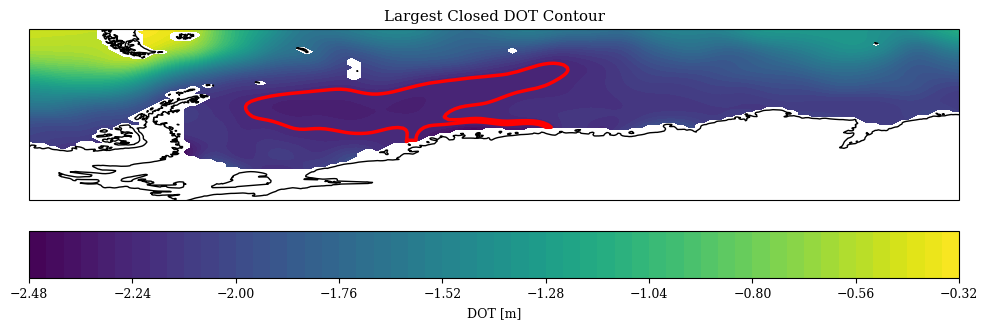

In [78]:
levels = np.linspace(np.nanmin(dot_masked), np.nanmax(dot_masked), 60)

valid = extract_closed_contours(
    lon_one_time, lat_one_time, dot_masked,
    levels, lon_min, lon_max,
    land_mask_on_dot, dist_km
)

if len(valid) == 0:
    print("No valid closed contours found.")
else:
    largest = max(valid, key=lambda c: c["area"])

    fig, ax = plt.subplots(
        figsize=(12, 8),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    plt.contourf(lon_one_time, lat_one_time, dot_masked, levels=60, cmap='viridis')

    seg = largest["vertices"]
    seg_lon = ((seg[:,0] + 180) % 360) - 180
    seg_lat = seg[:,1]

    plt.plot(seg_lon, seg_lat, '-', lw=2.5, color='red')

    plt.colorbar(orientation='horizontal', pad=0.05, label='DOT [m]')
    ax.coastlines()
    plt.title("Largest Closed DOT Contour")
    plt.show()


Largest closed contour level: -2.272 m


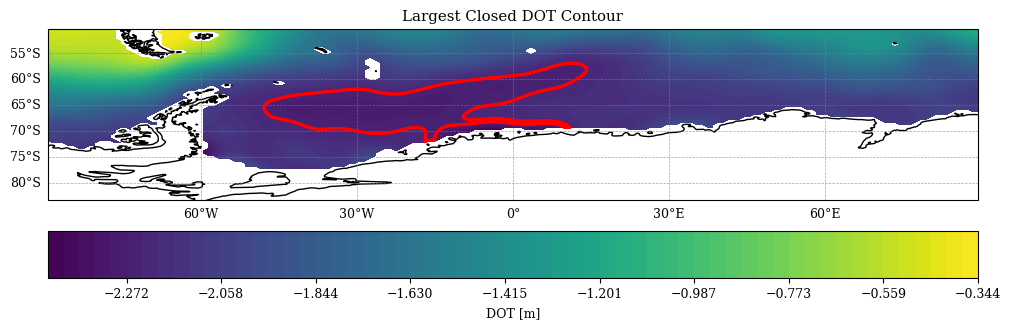

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- RAW DOT FIELD ---
dot = ds_reg.dot
t = dot.time[100]
one_dot = dot.sel(time=t)

lon = one_dot.longitude.values
lat = one_dot.latitude.values
Z = one_dot.values.T   # (lat, lon)

levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 60)

fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# --- MAIN CONTOUR PLOT (raw field, no masking) ---
cs = ax.contourf(
    lon, lat, Z,
    levels=levels,
    cmap='viridis',
    transform=ccrs.PlateCarree()
)

plt.colorbar(cs, orientation='horizontal', pad=0.05, label='DOT [m]')

# --- FIND CLOSED CONTOURS ---
closed = []

for level, seglist in zip(cs.levels, cs.allsegs):
    for seg in seglist:
        if seg.shape[0] < 4:
            continue

        # geometric closure
        if not np.allclose(seg[0], seg[-1], atol=1e-6):
            continue

        # compute area
        x = seg[:, 0]
        y = seg[:, 1]
        area = 0.5 * np.abs(
            np.dot(x, np.roll(y, 1)) -
            np.dot(y, np.roll(x, 1))
        )

        if area > 0:
            closed.append((level, seg, area))

# --- SELECT LARGEST CLOSED CONTOUR ---
if len(closed) > 0:
    best_level, best_seg, best_area = max(closed, key=lambda x: x[2])

    ax.plot(
        best_seg[:, 0],
        best_seg[:, 1],
        color='red',
        linewidth=2.5,
        transform=ccrs.PlateCarree(),
        zorder=10
    )

    print(f"Largest closed contour level: {best_level:.3f} m")
else:
    print("No closed contours found.")

# --- GRIDLINES + COASTLINES ---
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.7,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False

ax.coastlines()
plt.title("Largest Closed DOT Contour")
plt.show()


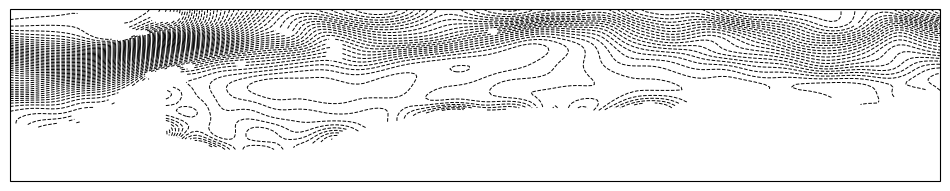

In [129]:
dot = ds_reg.dot
t = dot.time[100]
one_dot = dot.sel(time=t)

lon = one_dot.longitude.values
lat = one_dot.latitude.values
Z = one_dot.values.T   # (lat, lon)

# land mask on DOT grid
land_lat = ds.land_mask.latitude.values
land_lon = ds.land_mask.longitude.values
land_mask = ds.land_mask.values

from scipy.interpolate import RegularGridInterpolator

mask_land_interp = RegularGridInterpolator(
    (land_lat, land_lon),
    land_mask.T,
    bounds_error=False,
    fill_value=0
)

LAT, LON = np.meshgrid(lat, lon, indexing='ij')
land_mask_on_dot = mask_land_interp(np.stack([LAT, LON], axis=-1))

# raw contour
levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 60)

fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

cs = ax.contour(
    lon, lat, Z,
    levels=levels,
    colors='k',
    linewidths=0.7,
    transform=ccrs.PlateCarree()
)


In [135]:
from scipy.interpolate import RegularGridInterpolator

def largest_closed_ocean_contour(cs, lon, lat, land_mask_on_dot, tol=1e-6):

    mask_interp = RegularGridInterpolator(
        (lat, lon),
        land_mask_on_dot,
        bounds_error=False,
        fill_value=0
    )

    closed = []


    for level, seglist in zip(cs.levels, cs.allsegs):
        for seg in seglist:
            if seg.shape[0] < 4:
                continue

            # geometric closure
            if not np.allclose(seg[0], seg[-1], atol=tol):
                continue

            # continuity: kill stitched/broken contours
            d = np.sqrt(np.diff(seg[:,0])**2 + np.diff(seg[:,1])**2)
            if np.any(d > 2):   # ~20 km-ish
                continue

            # reject any vertex on land
            mask_vals = mask_interp(seg[:, ::-1])  # (lat, lon)
            if np.any(mask_vals > 0.5):
                continue

            # area (shoelace)
            x = seg[:, 0]
            y = seg[:, 1]
            area = 0.5 * np.abs(
                np.dot(x, np.roll(y, 1)) -
                np.dot(y, np.roll(x, 1))
            )

            closed.append((level, seg, area))

    if not closed:
        return None

    return max(closed, key=lambda x: x[2])


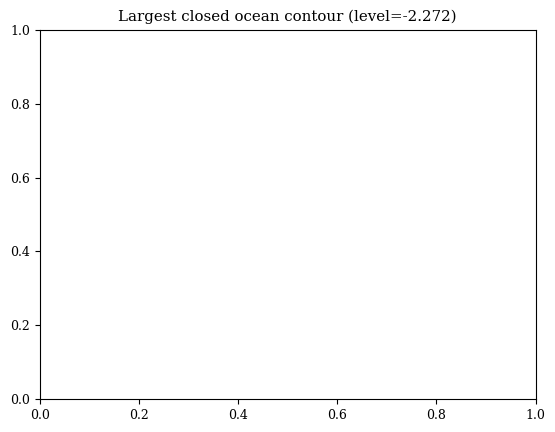

In [136]:
best = largest_closed_ocean_contour(cs, lon, lat, land_mask_on_dot)

if best is None:
    print("No valid closed ocean contours found.")


else:
    level, seg, area = best
    ax.contourf(
        lon, lat, Z,
        levels=60,
        cmap='viridis',
        transform=ccrs.PlateCarree()
    )
    ax.plot(
        seg[:,0], seg[:,1],
        color='red',
        linewidth=2.0,
        transform=ccrs.PlateCarree(),
        zorder=10
    )
    plt.colorbar(ax.collections[0], orientation='horizontal', pad=0.05, label='DOT [m]')
    ax.coastlines()
    plt.title(f"Largest closed ocean contour (level={level:.3f})")
    plt.show()


In [137]:
def extract_closed_contours(
    cs, lon, lat, land_mask_on_dot,
    continuity_thresh=0.2,   # degrees (~20 km)
    tol=1e-6
):

    # Interpolator for land mask
    mask_interp = RegularGridInterpolator(
        (lat, lon),
        land_mask_on_dot,
        bounds_error=False,
        fill_value=0
    )

    def segment_crosses_land(seg, n=10):
        """Check if any contour segment crosses land."""
        for i in range(len(seg) - 1):
            x0, y0 = seg[i]
            x1, y1 = seg[i+1]

            xs = np.linspace(x0, x1, n)
            ys = np.linspace(y0, y1, n)

            vals = mask_interp(np.vstack([ys, xs]).T)
            if np.any(vals > 0.5):
                return True
        return False

    closed = []

    for level, seglist in zip(cs.levels, cs.allsegs):
        for seg in seglist:

            # must have enough points
            if seg.shape[0] < 4:
                continue

            # must be geometrically closed
            if not np.allclose(seg[0], seg[-1], atol=tol):
                continue

            # continuity test (reject stitched/broken contours)
            d = np.sqrt(np.diff(seg[:,0])**2 + np.diff(seg[:,1])**2)
            if np.any(d > continuity_thresh):
                continue

            # reject contours that touch or cross land
            if segment_crosses_land(seg):
                continue

            # compute area (shoelace)
            x = seg[:, 0]
            y = seg[:, 1]
            area = 0.5 * np.abs(
                np.dot(x, np.roll(y, 1)) -
                np.dot(y, np.roll(x, 1))
            )

            closed.append({
                "level": level,
                "vertices": seg,
                "area": area
            })

    return closed


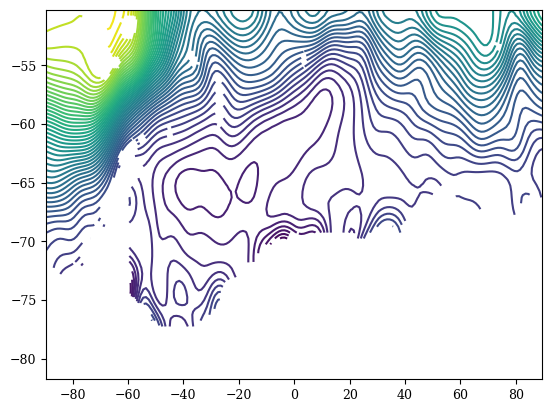

In [138]:
cs = plt.contour(lon_one_time, lat_one_time, dot_one_time, levels=60)


In [140]:
closed = extract_closed_contours(cs, lon_one_time, lat_one_time, land_mask_on_dot)


In [141]:
if closed:
    largest = max(closed, key=lambda c: c["area"])
else:
    print("No valid closed contours found.")


No valid closed contours found.


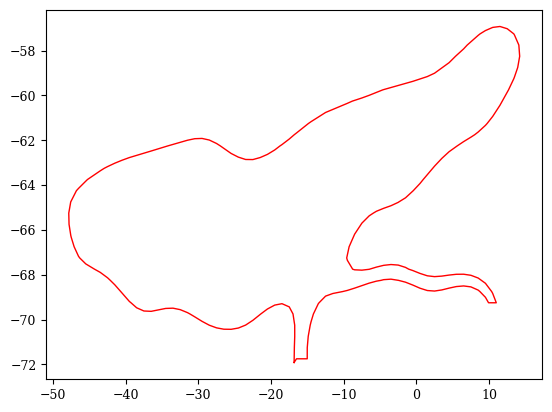

In [144]:
seg = largest["vertices"]
plt.plot(seg[:,0], seg[:,1], color='red', lw=1)